<a href="https://colab.research.google.com/github/cristinasarakefi-art/TugasAkhirS1/blob/main/Penelitianke3Untitled19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [4]:
from google.colab import files
upload = files.upload()

Saving Data Fix Penelitian Skripsi KNN.csv to Data Fix Penelitian Skripsi KNN.csv


In [5]:
import pandas as pd
df = pd.read_csv('/content/Data Fix Penelitian Skripsi KNN.csv', sep=';')
df

,Nama Lengkap,Bidang Minat,Norm_IPK Semester 3,Norm_Nilai Matkul DTL,Norm_Nilai Matkul DTT,Norm_Nilai Matkul DPK,Skor Minat TTL,Skor Minat TTT,Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,"0,6975",1,"0,5","0,5","0,2857","0,2857","0,7857"
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,"0,6975","0,9375","0,6875","0,5625","0,3571","0,7143","0,6429"
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,"0,6825",1,"0,8125","0,875","0,8214",1,"0,8929"
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,"0,62","0,875","0,6875","0,5","0,4643",0,"0,9286"
4,Epin Modjo,Teknik Komputer & Kendali,"0,7275","0,8125","0,6875","0,875","0,7857","0,5",1
...,...,...,...,...,...,...,...,...,...
95,Tesalonika Messakh,Teknik Komputer & Kendali,"0,8925","0,875","0,9375",1,"0,6786","0,5714","0,8214"
96,Reynaldi Hadi Djo,Teknik Komputer & Kendali,"0,73","0,75","0,625","0,875","0,5357","0,25","0,75"
97,Nafian Agazhi,Teknik Tenaga Listrik,"0,9525","0,875","0,9375",1,1,"0,3571","0,5"
98,Nover Morestu Ndun,Teknik Tenaga Listrik,"0,8075",1,1,1,"0,7857","0,5","0,5"


In [6]:
import pandas as pd
import numpy as np

# 1. Membaca file dengan separator titik koma (;) as strings to handle various numeric formats consistently
data = pd.read_csv('/content/Data Fix Penelitian Skripsi KNN.csv', sep=';', dtype=str)

# 2. Membersihkan spasi yang tidak sengaja ada di awal/akhir teks pada kolom teks
data['Bidang Minat'] = data['Bidang Minat'].str.strip()

# Columns that need to be converted to numeric and cleaned for commas/spaces
numeric_cols = [
    'Norm_Nilai Matkul DTL', 'Norm_Nilai Matkul DTT', 'Norm_Nilai Matkul DPK',
    'Norm_IPK Semester 3', 'Skor Minat TTL', 'Skor Minat TTT', 'Skor Minat TKK'
]

for col in numeric_cols:
    # Ensure it's string, remove spaces, replace comma with dot, then convert to float
    data[col] = data[col].str.replace(' ', '').str.replace(',', '.').astype(float)

# 3. Menampilkan 5 data teratas untuk memastikan data terbaca dengan benar
print("Data Mahasiswa Berhasil Dimasukkan dan Dibersihkan:")
display(data.head())

Data Mahasiswa Berhasil Dimasukkan dan Dibersihkan:


,Nama Lengkap,Bidang Minat,Norm_IPK Semester 3,Norm_Nilai Matkul DTL,Norm_Nilai Matkul DTT,Norm_Nilai Matkul DPK,Skor Minat TTL,Skor Minat TTT,Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,0.6975,1.0000,0.5000,0.5000,0.2857,0.2857,0.7857
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,0.6975,0.9375,0.6875,0.5625,0.3571,0.7143,0.6429
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,0.6825,1.0000,0.8125,0.8750,0.8214,1.0000,0.8929
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,0.6200,0.8750,0.6875,0.5000,0.4643,0.0000,0.9286
4,Epin Modjo,Teknik Komputer & Kendali,0.7275,0.8125,0.6875,0.8750,0.7857,0.5000,1.0000


In [11]:
# Menentukan kolom yang menjadi input (X) sesuai nama kolom di file Anda
kolom_fitur = ['Norm_Nilai Matkul DTL', 'Norm_Nilai Matkul DTT', 'Norm_Nilai Matkul DPK',
               'Norm_IPK Semester 3', 'Skor Minat TTL', 'Skor Minat TTT', 'Skor Minat TKK']
X = data[kolom_fitur]

# Menentukan kolom yang menjadi target/output (y)
y = data['Bidang Minat']

print("Fitur (X) dan Target (y) berhasil dipisahkan.")

Fitur (X) dan Target (y) berhasil dipisahkan.


In [15]:
from sklearn.model_selection import train_test_split

# Membagi data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah Data Latih (Training): {X_train.shape[0]} sampel")
print(f"Jumlah Data Uji (Testing): {X_test.shape[0]} sampel")

Jumlah Data Latih (Training): 80 sampel
Jumlah Data Uji (Testing): 20 sampel


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Daftar nilai K ganjil yang diminta untuk diuji
# Nilai K harus <= jumlah sampel data latih (X_train).
# X_train memiliki 8 sampel, jadi nilai K tidak boleh melebihi 8.
nilai_k = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

print("--- HASIL SIMULASI AKURASI ALGORITMA K-NN ---")

# Melakukan perulangan untuk setiap nilai K
for k in nilai_k:
    # 1. Inisialisasi model K-NN
    knn = KNeighborsClassifier(n_neighbors=k)

    # 2. Melatih model menggunakan data latih
    knn.fit(X_train, y_train)

    # 3. Memprediksi data uji
    y_pred = knn.predict(X_test)

    # 4. Menghitung persentase akurasi
    akurasi = accuracy_score(y_test, y_pred) * 100

    print(f"Nilai K = {k} -> Tingkat Akurasi Sistem: {akurasi:.2f}%")

--- HASIL SIMULASI AKURASI ALGORITMA K-NN ---
Nilai K = 2 -> Tingkat Akurasi Sistem: 90.00%
Nilai K = 3 -> Tingkat Akurasi Sistem: 90.00%
Nilai K = 4 -> Tingkat Akurasi Sistem: 85.00%
Nilai K = 5 -> Tingkat Akurasi Sistem: 90.00%
Nilai K = 6 -> Tingkat Akurasi Sistem: 90.00%
Nilai K = 7 -> Tingkat Akurasi Sistem: 90.00%
Nilai K = 8 -> Tingkat Akurasi Sistem: 85.00%
Nilai K = 9 -> Tingkat Akurasi Sistem: 80.00%
Nilai K = 10 -> Tingkat Akurasi Sistem: 80.00%
Nilai K = 11 -> Tingkat Akurasi Sistem: 80.00%


In [17]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# 1. BACA DATASET
df = pd.read_csv('/content/Data Fix Penelitian Skripsi KNN.csv', sep=';', decimal=',')
df['Bidang Minat'] = df['Bidang Minat'].str.strip()

# 2. DEFINISIKAN FITUR (X) DAN TARGET (y)
X = df[['Norm_IPK Semester 3', 'Norm_Nilai Matkul DTL', 'Norm_Nilai Matkul DTT',
        'Norm_Nilai Matkul DPK', 'Skor Minat TTL', 'Skor Minat TTT', 'Skor Minat TKK']]
y = df['Bidang Minat']

# 3. INISIALISASI MODEL & STRATIFIED K-FOLD
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. EKSEKUSI CROSS VALIDATION PER FOLD
print("=== HASIL PENGUJIAN STRATIFIED 5-FOLD CROSS VALIDATION ===")
fold_scores = []

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Training & Testing
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    # Hitung Akurasi
    acc = accuracy_score(y_test, y_pred)
    fold_scores.append(acc)

    print(f"Fold {fold}: Data Latih = {len(X_train)}, Data Uji = {len(X_test)} | Akurasi = {acc * 100:.2f}%")

# 5. RATA-RATA TOTAL AKURASI
print("-" * 58)
print(f"Rata-rata Akurasi Cross Validation: {np.mean(fold_scores) * 100:.2f}%")

=== HASIL PENGUJIAN STRATIFIED 5-FOLD CROSS VALIDATION ===
Fold 1: Data Latih = 80, Data Uji = 20 | Akurasi = 85.00%
Fold 2: Data Latih = 80, Data Uji = 20 | Akurasi = 90.00%
Fold 3: Data Latih = 80, Data Uji = 20 | Akurasi = 95.00%
Fold 4: Data Latih = 80, Data Uji = 20 | Akurasi = 100.00%
Fold 5: Data Latih = 80, Data Uji = 20 | Akurasi = 95.00%
----------------------------------------------------------
Rata-rata Akurasi Cross Validation: 93.00%


          LAPORAN EVALUASI KLASIFIKASI (K-NN)          

                           precision    recall  f1-score   support

Teknik Komputer & Kendali       0.92      0.82      0.87        28
    Teknik Telekomunikasi       0.97      0.95      0.96        37
    Teknik Tenaga Listrik       0.90      1.00      0.95        35

                 accuracy                           0.93       100
                macro avg       0.93      0.92      0.92       100
             weighted avg       0.93      0.93      0.93       100



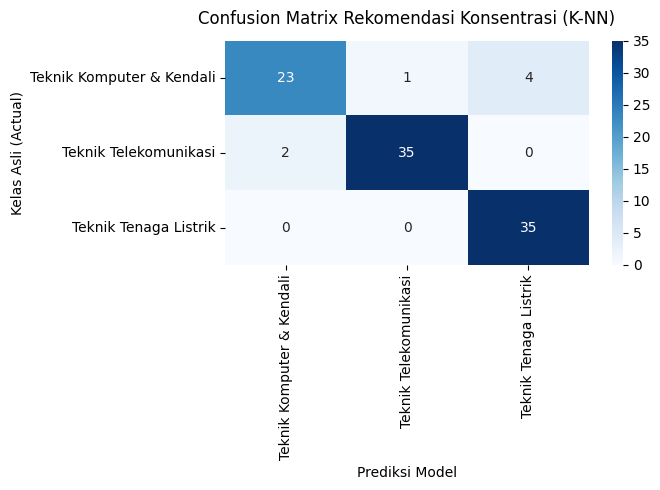


Grafik Confusion Matrix berhasil disimpan sebagai 'confusion_matrix_knn.png'


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Inisialisasi Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. MENDAPATKAN PREDIKSI DARI STRATIFIED CROSS VALIDATION
# Memprediksi data uji pada tiap fold secara objektif
y_pred = cross_val_predict(knn, X, y, cv=skf)

# 2. MENAMPILKAN CLASSIFICATION REPORT (Precision, Recall, F1-Score)
print("=======================================================")
print("          LAPORAN EVALUASI KLASIFIKASI (K-NN)          ")
print("=======================================================\n")
report = classification_report(y_true=y, y_pred=y_pred) # Changed y_pred=y_pred to y_true=y and y_true=y_pred to y_pred=y_pred for sklearn convention
print(report)

# 3. MEMBUAT VISUALISASI CONFUSION MATRIX (HEATMAP)
cm = confusion_matrix(y, y_pred)
labels = sorted(y.unique()) # Mengambil nama kelas konsentrasi (Listrik, Telkom, TKK)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix Rekomendasi Konsentrasi (K-NN)', fontsize=12, pad=12)
plt.xlabel('Prediksi Model', fontsize=10)
plt.ylabel('Kelas Asli (Actual)', fontsize=10)
plt.tight_layout()

# Menyimpan grafik sebagai gambar PNG untuk dimasukkan ke laporan Bab IV
plt.savefig('confusion_matrix_knn.png', dpi=300)
plt.show()

print("\nGrafik Confusion Matrix berhasil disimpan sebagai 'confusion_matrix_knn.png'")